# Preprocessing & Class Imbalance Resolution
This notebook prepares the raw data for modeling. We construct an imputation and scaling pipeline, visualize missing values, apply SMOTE to rebalance training samples, and visualize the feature correlations.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_all_years, get_train_test_split
from src.preprocessor import get_pipeline, fit_transform_train, transform_test, apply_smote

In [2]:
# Load and split
data_dir = os.path.join('..', 'data', 'raw')
df = load_all_years(data_dir)
X_train, X_test, y_train, y_test = get_train_test_split(df, test_size=0.2, random_state=42)

Raw ARFF files not found in data/raw/. Generating synthetic Polish bankruptcy dataset for demonstration.


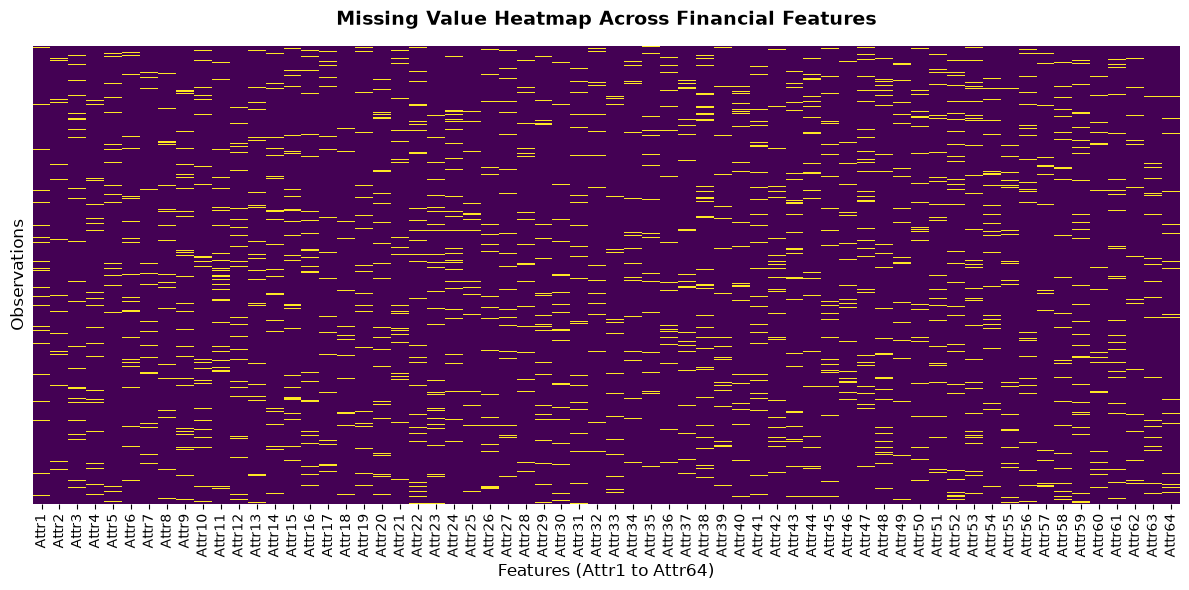

In [3]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.drop(columns=['class', 'year'], errors='ignore').isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap Across Financial Features', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Features (Attr1 to Attr64)', fontsize=12)
plt.ylabel('Observations', fontsize=12)

save_path_mv = os.path.join('..', 'reports', 'figures', 'missing_values_heatmap.png')
plt.tight_layout()
plt.savefig(save_path_mv, dpi=300)
plt.show()

In [4]:
# Preprocess features (Median Imputation + Standard Scaling)
pipeline = get_pipeline()
X_train_scaled = fit_transform_train(pipeline, X_train)
X_test_scaled = transform_test(pipeline, X_test)
print("Training scaling complete. Original shape:", X_train.shape, "Scaled shape:", X_train_scaled.shape)

Training scaling complete. Original shape: (800, 64) Scaled shape: (800, 64)


In [5]:
# Apply SMOTE
X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)
print("Resampling complete. Resampled shape:", X_train_res.shape)

Resampling complete. Resampled shape: (1564, 64)


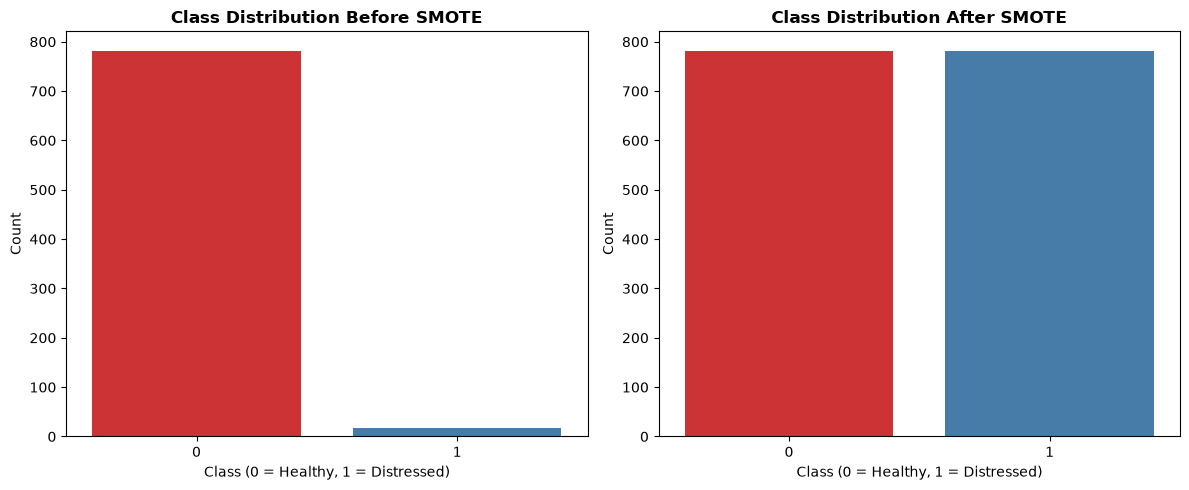

In [6]:
# Plot class distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette='Set1', hue=y_train, legend=False)
axes[0].set_title('Class Distribution Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class (0 = Healthy, 1 = Distressed)')
axes[0].set_ylabel('Count')

sns.countplot(x=y_train_res, ax=axes[1], palette='Set1', hue=y_train_res, legend=False)
axes[1].set_title('Class Distribution After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class (0 = Healthy, 1 = Distressed)')
axes[1].set_ylabel('Count')

save_path_smote = os.path.join('..', 'reports', 'figures', 'smote_class_comparison.png')
plt.tight_layout()
plt.savefig(save_path_smote, dpi=300)
plt.show()

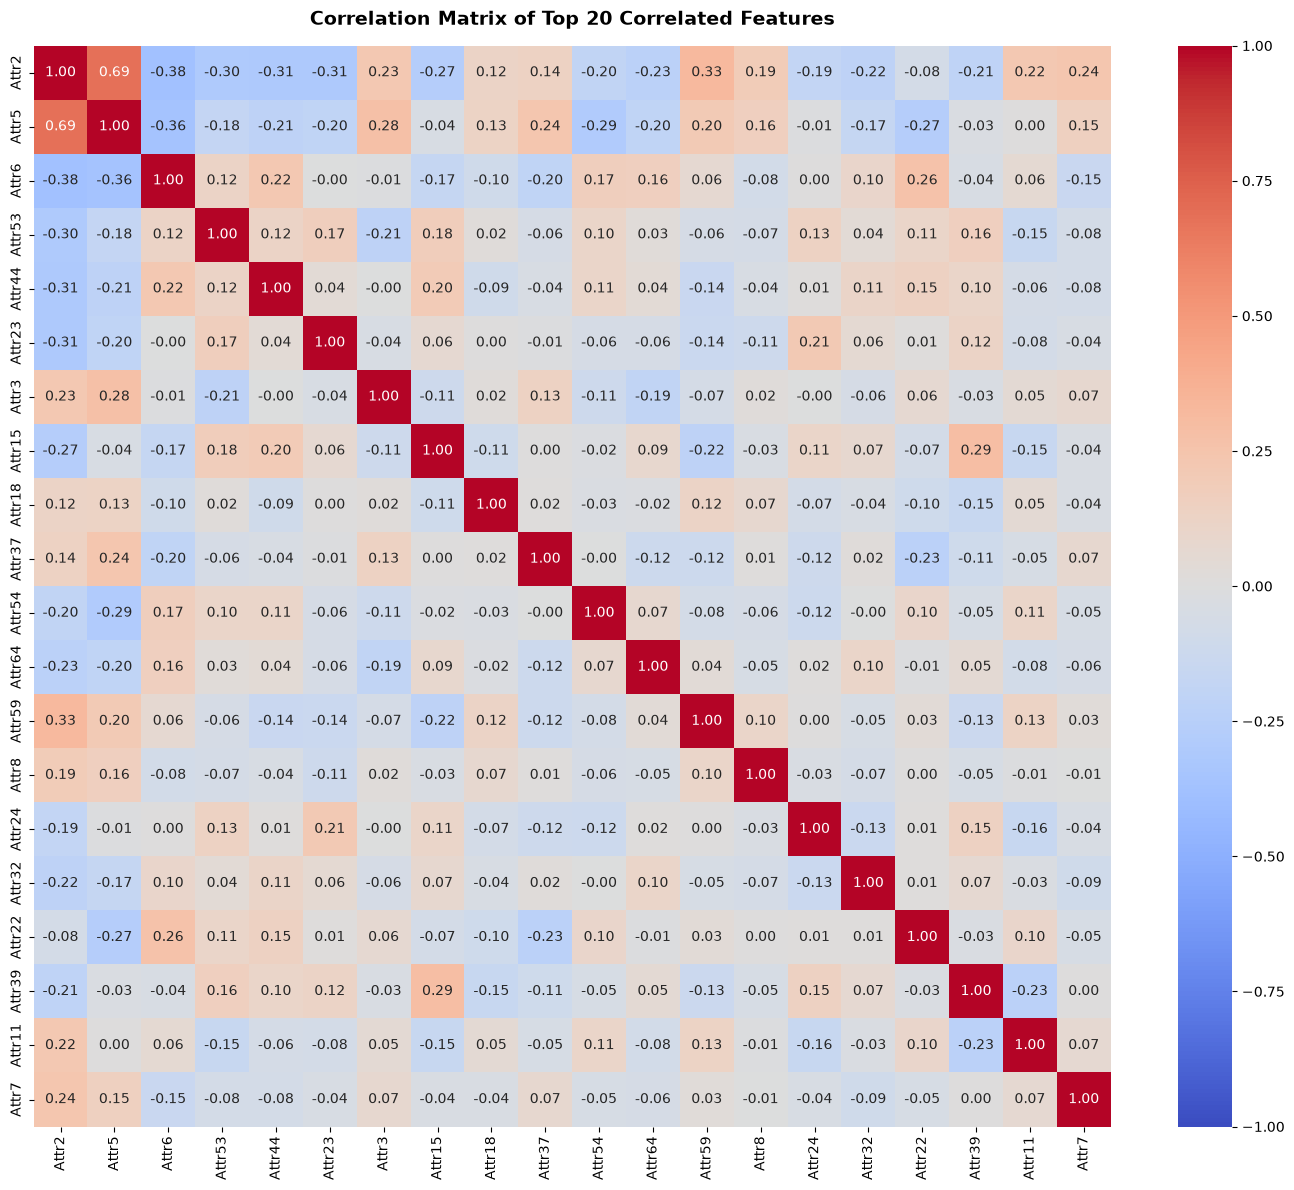

In [7]:
# Show correlation matrix of top 20 features correlated with target
train_res_df = pd.concat([X_train_res, y_train_res], axis=1)
target_corr = train_res_df.corr()[y_train_res.name].abs().sort_values(ascending=False)
top_20_cols = target_corr.index[1:21] # Exclude target itself

plt.figure(figsize=(14, 12))
top_20_corr = X_train_res[top_20_cols].corr()
sns.heatmap(top_20_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top 20 Correlated Features', fontsize=14, fontweight='bold', pad=15)

save_path_top20 = os.path.join('..', 'reports', 'figures', 'top_20_features_correlation.png')
plt.tight_layout()
plt.savefig(save_path_top20, dpi=300)
plt.show()